# Step 7 — Answer the three diagnostic questions

This notebook answers three questions:

1. **Health risk:** Is the startup constrained by runway, weak unit
   economics, or both?
2. **Failure archetype:** Which historical failure combination and
   sector-specific risk should founders investigate?
3. **Funding benchmark:** How does funding compare with similar companies,
   and how is relative funding associated with observed outcomes?

The three datasets remain separate. No company-level match between them
has been assumed.

## Interpretation limits

- The operating-metrics data is synthetic. It demonstrates a transparent
  diagnostic method but does not estimate real-world startup risk.
- The failure table contains failed startups only. It describes patterns
  among failures, not the probability that an active startup will fail.
- Some failure factors were not measured in every sector file. Missing
  factor coverage is not treated as a recorded absence.
- Crunchbase status is an observed label. Operating is not proof of
  success, and acquisition is not always a positive outcome.
- The funding benchmark is relative capitalization. True capital adequacy
  also requires burn, runway, and operating-plan data.

In [1]:
# Import the libraries used for the three analyses.
from pathlib import Path
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Find the project root when run from the root or notebooks folder.
BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURE_DIR = BASE_DIR / "outputs" / "figures"
TABLE_DIR = BASE_DIR / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")


def save_figure(file_name):
    # Save the current figure and display it in the notebook.
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / file_name, dpi=150, bbox_inches="tight")
    plt.show()


def format_usd(value):
    # Make large funding values easier to read.
    if pd.isna(value):
        return "Missing"
    if value >= 1_000_000_000:
        return "$" + f"{value / 1_000_000_000:.2f}B"
    if value >= 1_000_000:
        return "$" + f"{value / 1_000_000:.2f}M"
    if value >= 1_000:
        return "$" + f"{value / 1_000:.1f}K"
    return "$" + f"{value:,.0f}"

## Load the Step 5 feature tables

In [2]:
failure_file = PROCESSED_DIR / "failure_feature_table.csv"
crunchbase_file = PROCESSED_DIR / "crunchbase_feature_table.csv"
metrics_file = PROCESSED_DIR / "startup_metrics_feature_table.csv"

required_files = [failure_file, crunchbase_file, metrics_file]
missing_files = [str(file) for file in required_files if not file.exists()]
if missing_files:
    raise FileNotFoundError(
        f"Missing Step 5 files: {missing_files}. Run Step 5 first."
    )

failure = pd.read_csv(failure_file, low_memory=False)
crunchbase = pd.read_csv(crunchbase_file, low_memory=False)
metrics = pd.read_csv(metrics_file)

print(f"Failure records:          {len(failure):,}")
print(f"Crunchbase companies:     {len(crunchbase):,}")
print(f"Synthetic startup rows:   {len(metrics):,}")

Failure records:          409
Crunchbase companies:     66,368
Synthetic startup rows:   200


**Result note.** The analyses use 409 failed-startup records, 66,368
Crunchbase companies, and 200 synthetic startup-metric rows. These
populations answer different questions and are not merged.

# Question 1 — What is the startup's main health risk?

The existing health label uses two transparent thresholds:

- **High Risk:** runway below 6 months or LTV/CAC at or below 2.
- **Healthy:** runway of at least 12 months and LTV/CAC above 3.
- **Moderate Risk:** every remaining combination.

These thresholds are screening rules, not universal laws.

In [3]:
health_data = metrics[metrics["analysis_eligible"]].copy()


def calculate_health_status(row):
    if row["runway_months"] < 6 or row["ltv_cac_ratio"] <= 2:
        return "High Risk"
    if row["runway_months"] >= 12 and row["ltv_cac_ratio"] > 3:
        return "Healthy"
    return "Moderate Risk"


health_data["calculated_health_status"] = health_data.apply(
    calculate_health_status, axis=1
)

# Confirm that the simple rule reproduces the Step 5 label.
health_mismatches = (
    health_data["calculated_health_status"]
    != health_data["health_status"]
).sum()

runway_risk = health_data["runway_months"] < 6
unit_economics_risk = health_data["ltv_cac_ratio"] <= 2

health_data["primary_risk_signal"] = np.select(
    [
        runway_risk & unit_economics_risk,
        runway_risk & ~unit_economics_risk,
        ~runway_risk & unit_economics_risk,
        health_data["health_status"].eq("Healthy"),
    ],
    [
        "Runway and unit economics",
        "Runway only",
        "Unit economics only",
        "No immediate threshold breach",
    ],
    default="Watch zone",
)

action_map = {
    "Runway and unit economics":
        "Reduce burn immediately and retest acquisition economics.",
    "Runway only":
        "Build a weekly cash plan and test burn reduction or financing.",
    "Unit economics only":
        "Validate CAC by channel and LTV by customer cohort.",
    "Watch zone":
        "Track runway and LTV/CAC monthly; test the weaker metric first.",
    "No immediate threshold breach":
        "Monitor trends before adding fixed cost.",
}
health_data["recommended_investigation"] = health_data[
    "primary_risk_signal"
].map(action_map)

health_summary = (
    health_data["health_status"]
    .value_counts()
    .reindex(["High Risk", "Moderate Risk", "Healthy"], fill_value=0)
    .rename_axis("Health status")
    .reset_index(name="Startups")
)
health_summary["Share"] = (
    100 * health_summary["Startups"] / len(health_data)
).round(1)

signal_order = [
    "Runway only",
    "Unit economics only",
    "Runway and unit economics",
    "Watch zone",
    "No immediate threshold breach",
]
signal_summary = (
    health_data["primary_risk_signal"]
    .value_counts()
    .reindex(signal_order, fill_value=0)
    .rename_axis("Primary signal")
    .reset_index(name="Startups")
)

health_output_columns = [
    "startup_id", "stage", "category_group", "mrr_usd",
    "runway_months", "ltv_cac_ratio", "health_status",
    "primary_risk_signal", "recommended_investigation",
]
health_data[health_output_columns].to_csv(
    TABLE_DIR / "step7_health_risk_results.csv",
    index=False,
)
health_summary.to_csv(
    TABLE_DIR / "step7_health_risk_summary.csv",
    index=False,
)

print(f"Health-rule mismatches: {health_mismatches}")
print()
print("Health-status summary:")
print(health_summary.to_string(index=False))
print()
print("Primary diagnostic signal:")
print(signal_summary.to_string(index=False))

Health-rule mismatches: 0

Health-status summary:
Health status  Startups  Share
    High Risk       128   64.0
Moderate Risk        60   30.0
      Healthy        12    6.0

Primary diagnostic signal:
               Primary signal  Startups
                  Runway only        65
          Unit economics only        35
    Runway and unit economics        28
                   Watch zone        60
No immediate threshold breach        12


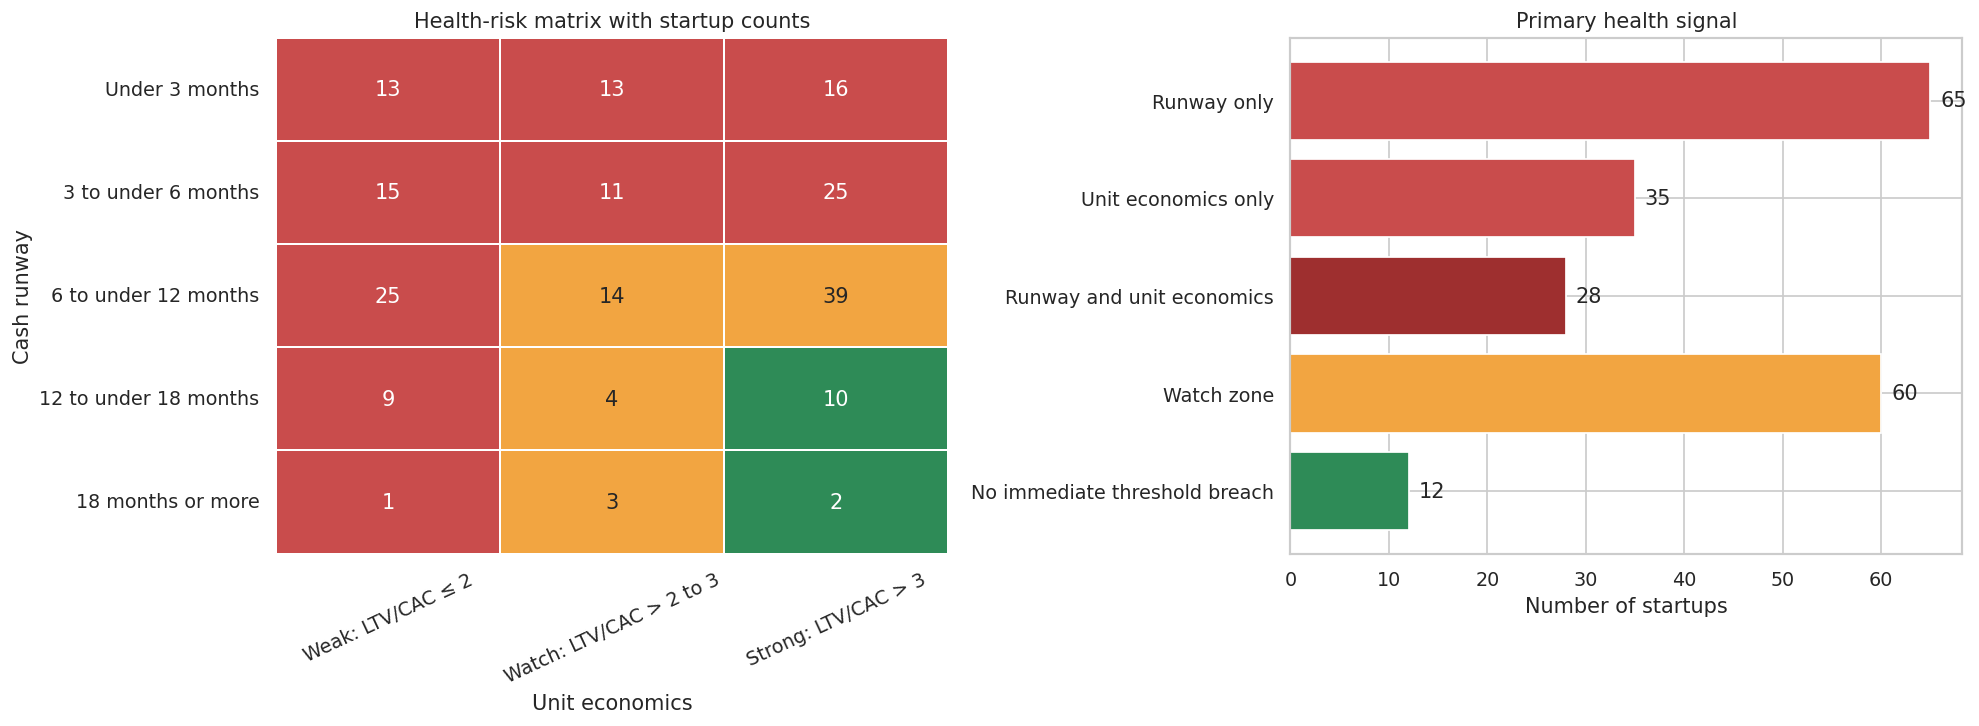

In [4]:
# Build a compact matrix of runway and unit-economics conditions.
runway_order = [
    "Under 3 months",
    "3 to under 6 months",
    "6 to under 12 months",
    "12 to under 18 months",
    "18 months or more",
]
unit_order = [
    "Weak: LTV/CAC ≤ 2",
    "Watch: LTV/CAC > 2 to 3",
    "Strong: LTV/CAC > 3",
]

health_data["unit_economics_band"] = pd.cut(
    health_data["ltv_cac_ratio"],
    bins=[-np.inf, 2, 3, np.inf],
    labels=unit_order,
    include_lowest=True,
)

risk_counts = pd.crosstab(
    health_data["runway_band"],
    health_data["unit_economics_band"],
).reindex(index=runway_order, columns=unit_order, fill_value=0)

# 2 = High Risk, 1 = Moderate Risk, 0 = Healthy.
risk_colors = pd.DataFrame(
    [
        [2, 2, 2],
        [2, 2, 2],
        [2, 1, 1],
        [2, 1, 0],
        [2, 1, 0],
    ],
    index=runway_order,
    columns=unit_order,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    risk_colors,
    annot=risk_counts,
    fmt="d",
    cmap=ListedColormap(["#2E8B57", "#F2A541", "#C94C4C"]),
    vmin=-0.5,
    vmax=2.5,
    cbar=False,
    linewidths=1,
    linecolor="white",
    ax=axes[0],
)
axes[0].set_title("Health-risk matrix with startup counts")
axes[0].set_xlabel("Unit economics")
axes[0].set_ylabel("Cash runway")
axes[0].tick_params(axis="x", rotation=25)
axes[0].tick_params(axis="y", rotation=0)

signal_plot = signal_summary.iloc[::-1]
signal_colors = {
    "Runway only": "#C94C4C",
    "Unit economics only": "#C94C4C",
    "Runway and unit economics": "#9E2F2F",
    "Watch zone": "#F2A541",
    "No immediate threshold breach": "#2E8B57",
}
axes[1].barh(
    signal_plot["Primary signal"],
    signal_plot["Startups"],
    color=[
        signal_colors[label]
        for label in signal_plot["Primary signal"]
    ],
)
axes[1].set_title("Primary health signal")
axes[1].set_xlabel("Number of startups")
axes[1].set_ylabel("")
for position, value in enumerate(signal_plot["Startups"]):
    axes[1].text(value + 1, position, str(value), va="center")

save_figure("step7_01_health_risk.png")

**Answer to Question 1.** In this synthetic sample, 128 startups (64%)
are High Risk, 60 (30%) are Moderate Risk, and 12 (6%) are Healthy.
Runway is the more common immediate bottleneck: 93 startups breach the
runway threshold, compared with 63 that breach the unit-economics
threshold; 28 breach both.

The practical sequence is:

1. If both thresholds are breached, reduce burn and stop scaling weak
   acquisition channels.
2. If runway alone is weak, test a cash-extension plan before optimizing
   growth.
3. If unit economics alone is weak, validate CAC by channel and LTV by
   customer cohort before increasing acquisition spend.

Because the data is synthetic, these counts demonstrate the method rather
than describe the real startup population.

# Question 2 — Which historical failure archetype should be tested?

An archetype is the exact combination of failure factors recorded for a
startup. Exact combinations preserve the fact that startup failures are
usually multi-causal.

The sector comparison also identifies the most frequent secondary factor
after large-incumbent and general competition factors.

In [5]:
failure_flags = [
    "Giants", "No Budget", "Competition", "Poor Market Fit",
    "Acquisition Stagnation", "Platform Dependency",
    "High Operational Costs", "Monetization Failure", "Niche Limits",
    "Execution Flaws", "Trend Shifts", "Toxicity/Trust Issues",
    "Regulatory Pressure", "Overhype",
]

# Most frequent exact combinations across the full failure table.
combination_summary = (
    failure["risk_combination"]
    .value_counts()
    .rename_axis("Failure combination")
    .reset_index(name="Records")
)
combination_summary["Share of failure records"] = (
    100 * combination_summary["Records"] / len(failure)
).round(1)

# Most frequent exact combination within each sector.
sector_combination_counts = (
    failure.groupby(["Sector", "risk_combination"])
    .size()
    .reset_index(name="Combination records")
)
sector_top_combination = (
    sector_combination_counts
    .sort_values(
        ["Sector", "Combination records", "risk_combination"],
        ascending=[True, False, True],
    )
    .groupby("Sector", as_index=False)
    .head(1)
    .rename(columns={"risk_combination": "Top exact combination"})
)

sector_sizes = failure.groupby("Sector").size().rename("Sector records")
sector_top_combination = sector_top_combination.merge(
    sector_sizes,
    on="Sector",
)
sector_top_combination["Top combination share"] = (
    100
    * sector_top_combination["Combination records"]
    / sector_top_combination["Sector records"]
).round(1)

# Find the most common sector-specific factor after the two dominant
# competition variables.
secondary_flags = [
    flag for flag in failure_flags
    if flag not in ["Giants", "Competition"]
]
sector_factor_rates = (
    failure.groupby("Sector")[secondary_flags].mean() * 100
)
sector_secondary = (
    sector_factor_rates
    .stack(future_stack=True)
    .dropna()
    .rename("Secondary factor share")
    .reset_index()
    .rename(columns={"level_1": "Top secondary factor"})
    .sort_values(
        ["Sector", "Secondary factor share", "Top secondary factor"],
        ascending=[True, False, True],
    )
    .groupby("Sector", as_index=False)
    .head(1)
)

competitive_pair = (
    (
        failure["Giants"].eq(1)
        & failure["Competition"].eq(1)
    )
    .groupby(failure["Sector"])
    .mean()
    .mul(100)
    .round(1)
    .rename("Large-incumbent plus competition share")
    .reset_index()
)

recommended_tests = {
    "High Operational Costs":
        "Audit unit margin, delivery cost, and fixed-cost capacity.",
    "Acquisition Stagnation":
        "Measure conversion, activation, and retention by segment.",
    "Poor Market Fit":
        "Run problem and willingness-to-pay interviews by segment.",
    "No Budget":
        "Stress-test runway, gross margin, and the financing plan.",
    "Niche Limits":
        "Test market size, adjacent segments, and repeatable use cases.",
    "Monetization Failure":
        "Test pricing, packaging, and paid conversion.",
    "Execution Flaws":
        "Review delivery cycle time, defects, and ownership gaps.",
    "Trend Shifts":
        "Test whether demand moved to another use case or channel.",
}

sector_archetype = (
    sector_top_combination
    .merge(sector_secondary, on="Sector")
    .merge(competitive_pair, on="Sector")
)
sector_archetype["Recommended investigation"] = sector_archetype[
    "Top secondary factor"
].map(recommended_tests).fillna(
    "Review customer evidence behind the recorded factor."
)

combination_summary.to_csv(
    TABLE_DIR / "step7_failure_combination_summary.csv",
    index=False,
)
sector_archetype.to_csv(
    TABLE_DIR / "step7_failure_archetype_by_sector.csv",
    index=False,
)
failure[[
    "failure_record_id", "Name", "Sector", "risk_combination",
    "failure_factor_count", "funding_band", "operating_years",
]].to_csv(
    TABLE_DIR / "step7_failure_archetype_results.csv",
    index=False,
)

overall_display = combination_summary.head(10).copy()
overall_display["Share of failure records"] = overall_display[
    "Share of failure records"
].map(lambda value: f"{value:.1f}%")

sector_display = sector_archetype[[
    "Sector", "Sector records", "Top exact combination",
    "Top combination share", "Top secondary factor",
    "Secondary factor share", "Recommended investigation",
]].copy()
sector_display["Top combination share"] = sector_display[
    "Top combination share"
].map(lambda value: f"{value:.1f}%")
sector_display["Secondary factor share"] = sector_display[
    "Secondary factor share"
].map(lambda value: f"{value:.1f}%")

print("Most frequent exact failure combinations:")
print(overall_display.to_string(index=False))
print()
print("Sector-specific diagnostic map:")
print(sector_display.to_string(index=False))

Most frequent exact failure combinations:
                                  Failure combination  Records Share of failure records
        Giants + Competition + Acquisition Stagnation       42                    10.3%
                                 Giants + Competition       42                    10.3%
               Giants + Competition + Execution Flaws       17                     4.2%
                     Giants + No Budget + Competition       14                     3.4%
                                Giants + Niche Limits       12                     2.9%
               Giants + Competition + Poor Market Fit       12                     2.9%
                  Giants + Competition + Trend Shifts       10                     2.4%
Giants + Competition + Poor Market Fit + Niche Limits        9                     2.2%
                      Giants + Acquisition Stagnation        8                     2.0%
                                          Competition        8                

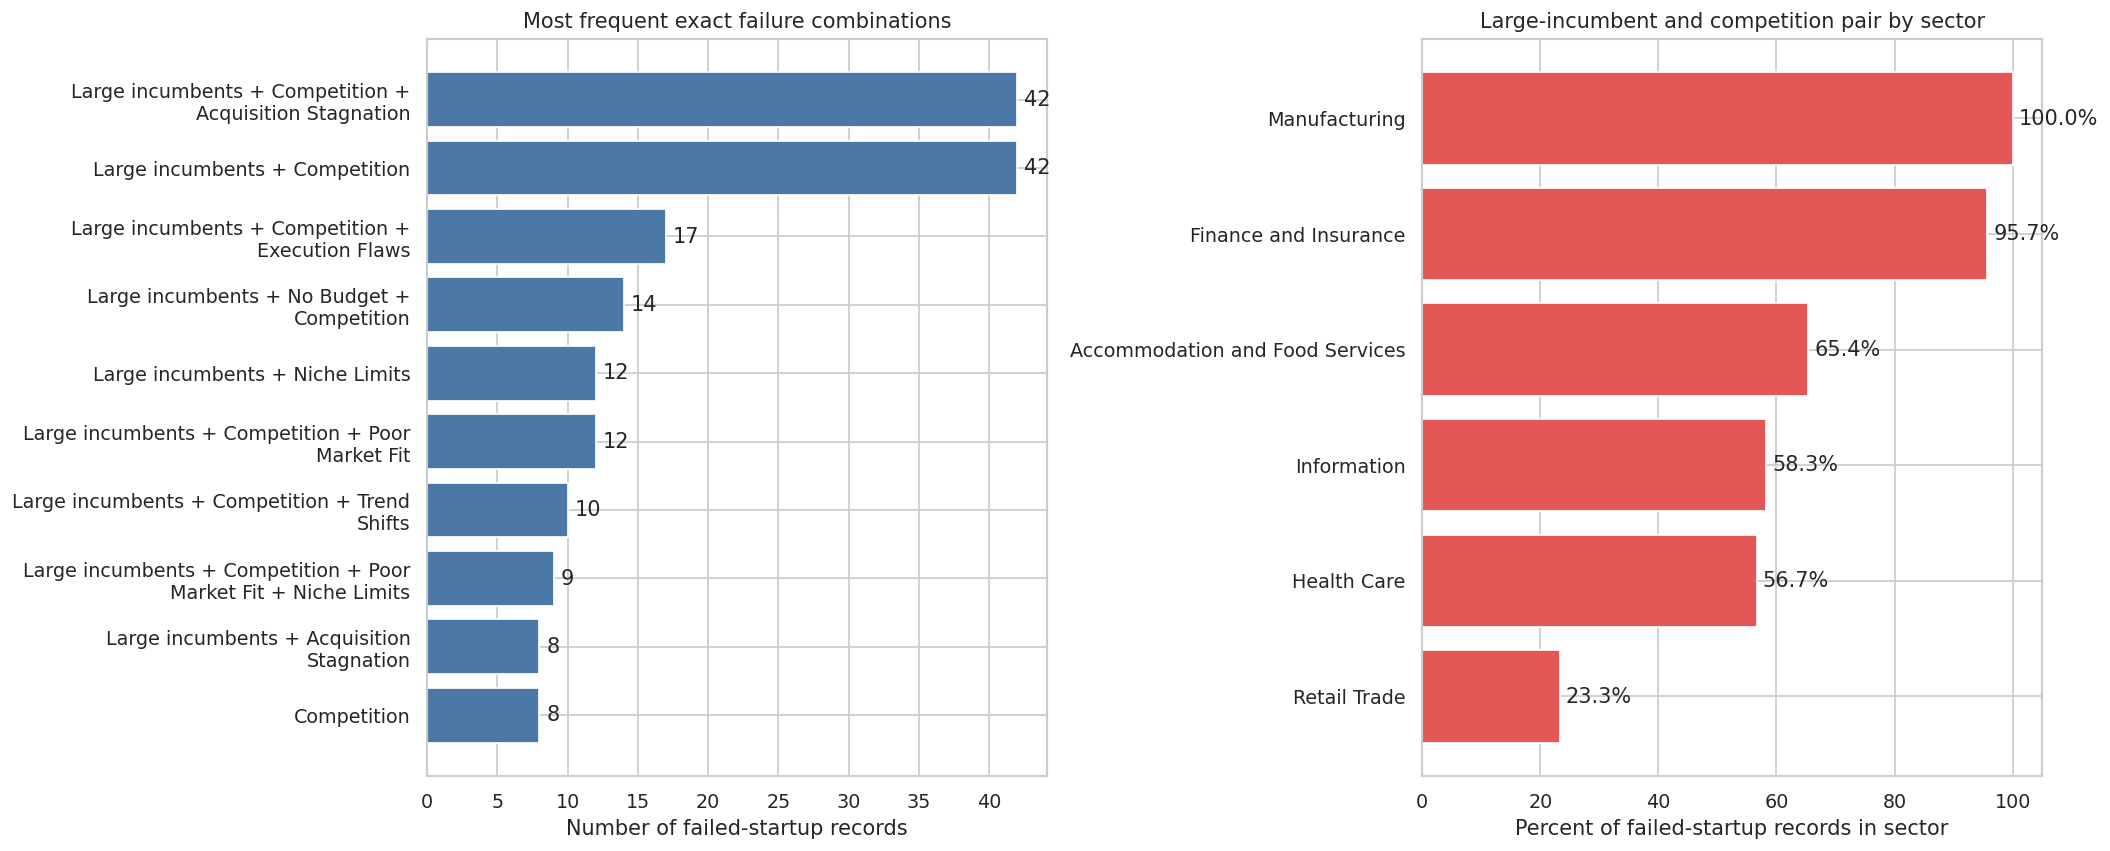

In [6]:
top_combinations = combination_summary.head(10).iloc[::-1].copy()
top_combinations["Chart label"] = top_combinations[
    "Failure combination"
].str.replace("Giants", "Large incumbents", regex=False).map(
    lambda label: textwrap.fill(label, width=38)
)

pair_by_sector = sector_archetype.sort_values(
    "Large-incumbent plus competition share"
)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

axes[0].barh(
    top_combinations["Chart label"],
    top_combinations["Records"],
    color="#4C78A8",
)
axes[0].set_title("Most frequent exact failure combinations")
axes[0].set_xlabel("Number of failed-startup records")
axes[0].set_ylabel("")
for position, value in enumerate(top_combinations["Records"]):
    axes[0].text(value + 0.5, position, str(value), va="center")

axes[1].barh(
    pair_by_sector["Sector"],
    pair_by_sector["Large-incumbent plus competition share"],
    color="#E45756",
)
axes[1].set_title(
    "Large-incumbent and competition pair by sector"
)
axes[1].set_xlabel("Percent of failed-startup records in sector")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 105)
for position, value in enumerate(
    pair_by_sector["Large-incumbent plus competition share"]
):
    axes[1].text(value + 1, position, f"{value:.1f}%", va="center")

save_figure("step7_02_failure_archetypes.png")

**Answer to Question 2.** Competitive pressure is the dominant historical
archetype. Large incumbents and competition occur together in 238 of 409
failure records (58.2%). The two most frequent exact combinations are
Large incumbents + Competition and Large incumbents + Competition +
Acquisition stagnation, with 42 records each.

The most useful next test depends on sector:

- Accommodation and Food Services: high operating costs (53.8%). Audit
  unit margin and capacity cost.
- Finance and Insurance: acquisition stagnation (25.5%). Test funnel,
  activation, and retention.
- Health Care: poor market fit (46.7%). Test the problem and willingness
  to pay by customer segment.
- Information: acquisition stagnation (34.6%). Diagnose acquisition and
  retention.
- Manufacturing: no budget (53.3%). Stress-test runway, margins, and
  financing requirements.
- Retail Trade: niche limits (33.3%). Test adjacent segments and market
  size.

These are hypotheses from historical post-mortems. Exact combinations are
fragmented, sector samples are small, and factor coverage differs across
sector files.

# Question 3 — How does funding compare with similar companies?

Comparable cohorts use the Step 5 peer definition:

**Primary category + country + founding-period cohort**

A cohort is included only when it has at least 30 companies with reported
funding and at least 5 acquired or IPO records with reported funding.
Unknown category, country, and founding-period values are excluded.

In [7]:
funding_base = crunchbase[
    crunchbase["funding_total_usd"].notna()
    & crunchbase["primary_category"].ne("Unknown")
    & crunchbase["country_code"].ne("UNKNOWN")
    & crunchbase["founded_cohort"].ne("Unknown")
].copy()

funding_base["observed_exit"] = funding_base["status"].isin(
    ["acquired", "ipo"]
)

cohort_eligibility = (
    funding_base.groupby("peer_cohort")
    .agg(
        funding_records=("name", "size"),
        observed_exit_records=("observed_exit", "sum"),
    )
)
eligible_cohorts = cohort_eligibility[
    (cohort_eligibility["funding_records"] >= 30)
    & (cohort_eligibility["observed_exit_records"] >= 5)
].index

funding_benchmark = funding_base[
    funding_base["peer_cohort"].isin(eligible_cohorts)
].copy()

# Rank each company against companies in the same peer cohort.
funding_benchmark["funding_percentile"] = (
    funding_benchmark.groupby("peer_cohort")["funding_total_usd"]
    .rank(pct=True, method="average")
)

quartile_order = [
    "Bottom quarter",
    "Lower-middle quarter",
    "Upper-middle quarter",
    "Top quarter",
]
funding_benchmark["funding_quartile"] = pd.cut(
    funding_benchmark["funding_percentile"],
    bins=[0, 0.25, 0.50, 0.75, 1],
    labels=quartile_order,
    include_lowest=True,
)

funding_benchmark["capitalization_position"] = np.select(
    [
        funding_benchmark["funding_percentile"] <= 0.25,
        funding_benchmark["funding_percentile"] > 0.75,
    ],
    [
        "Below peer Q1",
        "Above peer Q3",
    ],
    default="Within peer middle 50%",
)

cohort_stats = (
    funding_benchmark.groupby("peer_cohort")
    .agg(
        peer_funding_records=("name", "size"),
        peer_funding_q1_usd=(
            "funding_total_usd",
            lambda values: values.quantile(0.25),
        ),
        peer_median_funding_usd=("funding_total_usd", "median"),
        peer_funding_q3_usd=(
            "funding_total_usd",
            lambda values: values.quantile(0.75),
        ),
        peer_operating_share_pct=(
            "status",
            lambda values: 100 * values.eq("operating").mean(),
        ),
        peer_closed_share_pct=(
            "status",
            lambda values: 100 * values.eq("closed").mean(),
        ),
        peer_observed_exit_share_pct=(
            "status",
            lambda values:
                100 * values.isin(["acquired", "ipo"]).mean(),
        ),
    )
    .reset_index()
)

exit_median = (
    funding_benchmark[funding_benchmark["observed_exit"]]
    .groupby("peer_cohort")["funding_total_usd"]
    .median()
    .rename("peer_observed_exit_median_funding_usd")
    .reset_index()
)
cohort_stats = cohort_stats.merge(exit_median, on="peer_cohort")

funding_benchmark = funding_benchmark.merge(
    cohort_stats,
    on="peer_cohort",
    how="left",
)
funding_benchmark["funding_vs_observed_exit_median"] = np.where(
    funding_benchmark["funding_total_usd"]
    >= funding_benchmark[
        "peer_observed_exit_median_funding_usd"
    ],
    "At or above observed-exit median",
    "Below observed-exit median",
)

status_order = ["operating", "closed", "acquired", "ipo"]
quartile_outcomes = (
    pd.crosstab(
        funding_benchmark["funding_quartile"],
        funding_benchmark["status"],
        normalize="index",
    ) * 100
).reindex(
    index=quartile_order,
    columns=status_order,
    fill_value=0,
)
quartile_outcomes["Observed exit"] = (
    quartile_outcomes["acquired"]
    + quartile_outcomes["ipo"]
)
quartile_outcomes["Companies"] = (
    funding_benchmark.groupby(
        "funding_quartile",
        observed=False,
    ).size().reindex(quartile_order)
)

benchmark_columns = [
    "name", "primary_category", "country_code", "founded_cohort",
    "status", "funding_total_usd", "peer_cohort",
    "funding_percentile", "funding_quartile",
    "capitalization_position", "peer_funding_records",
    "peer_funding_q1_usd", "peer_median_funding_usd",
    "peer_funding_q3_usd",
    "peer_observed_exit_median_funding_usd",
    "funding_vs_observed_exit_median",
    "peer_operating_share_pct", "peer_closed_share_pct",
    "peer_observed_exit_share_pct",
]
funding_benchmark[benchmark_columns].to_csv(
    TABLE_DIR / "step7_funding_benchmark_results.csv",
    index=False,
)
cohort_stats.to_csv(
    TABLE_DIR / "step7_funding_cohort_summary.csv",
    index=False,
)
quartile_outcomes.to_csv(
    TABLE_DIR / "step7_funding_position_outcomes.csv"
)

outcome_display = quartile_outcomes.reset_index().rename(columns={
    "funding_quartile": "Peer funding position",
    "operating": "Operating",
    "closed": "Closed",
    "acquired": "Acquired",
    "ipo": "IPO",
})
for column in [
    "Operating", "Closed", "Acquired", "IPO", "Observed exit"
]:
    outcome_display[column] = outcome_display[column].map(
        lambda value: f"{value:.1f}%"
    )

largest_cohorts = (
    cohort_stats
    .sort_values("peer_funding_records", ascending=False)
    .head(10)
    .copy()
)
for column in [
    "peer_funding_q1_usd", "peer_median_funding_usd",
    "peer_funding_q3_usd",
    "peer_observed_exit_median_funding_usd",
]:
    largest_cohorts[column] = largest_cohorts[column].map(format_usd)
for column in [
    "peer_operating_share_pct", "peer_closed_share_pct",
    "peer_observed_exit_share_pct",
]:
    largest_cohorts[column] = largest_cohorts[column].map(
        lambda value: f"{value:.1f}%"
    )

print(f"Eligible peer cohorts: {len(eligible_cohorts):,}")
print(
    "Companies in funding benchmark: "
    f"{len(funding_benchmark):,}"
)
print()
print("Observed outcomes by funding position within peer cohort:")
print(outcome_display.to_string(index=False))
print()
print("Ten largest eligible peer cohorts:")
print(largest_cohorts.to_string(index=False))

Eligible peer cohorts: 97
Companies in funding benchmark: 15,878

Observed outcomes by funding position within peer cohort:
Peer funding position Operating Closed Acquired  IPO Observed exit  Companies
       Bottom quarter     82.9%   9.7%     6.0% 1.5%          7.5%       3919
 Lower-middle quarter     76.3%   8.1%    13.4% 2.1%         15.5%       3997
 Upper-middle quarter     71.5%   7.0%    18.6% 3.0%         21.6%       3947
          Top quarter     69.8%   4.2%    17.5% 8.5%         26.0%       4015

Ten largest eligible peer cohorts:
                    peer_cohort  peer_funding_records peer_funding_q1_usd peer_median_funding_usd peer_funding_q3_usd peer_operating_share_pct peer_closed_share_pct peer_observed_exit_share_pct peer_observed_exit_median_funding_usd
Biotechnology | USA | 2005-2009                   863              $1.63M                  $7.27M             $36.11M                    80.0%                  4.5%                        15.5%                         

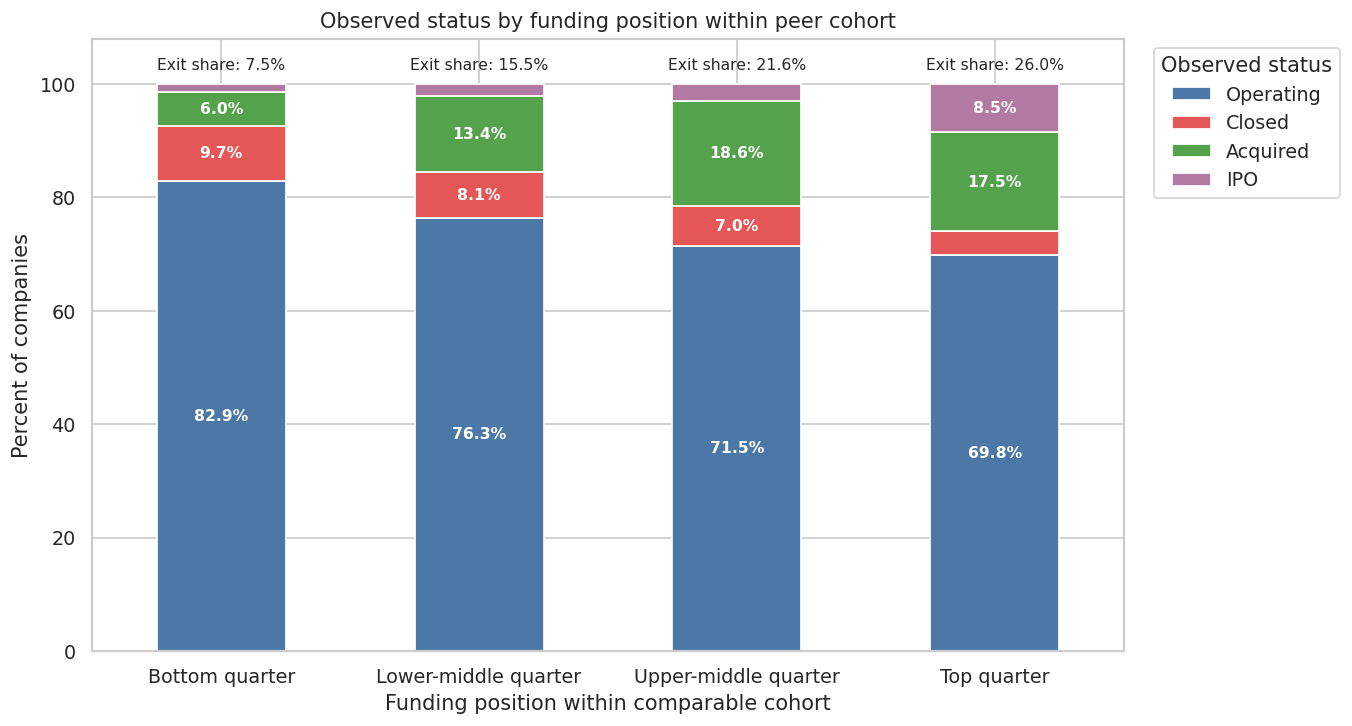

In [8]:
outcome_plot = quartile_outcomes[status_order].copy()
outcome_plot.columns = ["Operating", "Closed", "Acquired", "IPO"]

ax = outcome_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=["#4C78A8", "#E45756", "#54A24B", "#B279A2"],
)
ax.set_title("Observed status by funding position within peer cohort")
ax.set_xlabel("Funding position within comparable cohort")
ax.set_ylabel("Percent of companies")
ax.set_ylim(0, 108)
ax.set_xticklabels(quartile_order, rotation=0)
ax.legend(
    title="Observed status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

# Label only segments large enough to read.
for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value >= 5 else ""
        for value in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=9,
        fontweight="bold",
    )

for position, exit_share in enumerate(
    quartile_outcomes["Observed exit"]
):
    ax.text(
        position,
        102,
        f"Exit share: {exit_share:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

save_figure("step7_03_funding_benchmark.png")

**Answer to Question 3.** The reliable benchmark covers 97 cohorts and
15,878 companies with reported funding. Within these comparable cohorts,
the observed acquired-or-IPO share rises from 7.5% in the bottom funding
quarter to 26.0% in the top quarter. The closed share falls from 9.7% to
4.2%.

A startup below its cohort's first funding quartile is relatively
undercapitalized. A startup between the first and third quartiles is
inside the usual peer range. A startup above the third quartile is highly
capitalized relative to peers. This does not establish actual cash
adequacy or causation. Better outcomes may precede additional funding, and
12,785 Crunchbase companies have missing funding totals.

For a client diagnosis, combine relative funding with burn and runway:

- Below peer Q1 and short runway: investigate financing need and whether
  the operating plan is too capital-intensive.
- Inside the peer range: focus on capital productivity and milestones.
- Above peer Q3: test whether traction and operating progress justify the
  amount of capital consumed.

# Final answers and recommended next tests

In [9]:
bottom_exit_share = quartile_outcomes.loc[
    "Bottom quarter", "Observed exit"
]
top_exit_share = quartile_outcomes.loc[
    "Top quarter", "Observed exit"
]

diagnostic_summary = pd.DataFrame([
    {
        "Question": "1. Health risk",
        "Dataset-level answer":
            "Runway is the most common immediate bottleneck.",
        "Evidence":
            "93 runway breaches, 63 unit-economics breaches, "
            "and 28 startups breaching both.",
        "Recommended next test":
            "Review weekly cash, burn reduction, CAC by channel, "
            "and LTV by customer cohort.",
    },
    {
        "Question": "2. Failure archetype",
        "Dataset-level answer":
            "Competitive pressure is the dominant historical pattern.",
        "Evidence":
            "Large incumbents and competition co-occur in "
            "58.2% of failure records.",
        "Recommended next test":
            "Use the sector-specific secondary factor to choose "
            "the first customer, funnel, cost, or market test.",
    },
    {
        "Question": "3. Funding benchmark",
        "Dataset-level answer":
            "Higher relative funding is associated with more "
            "observed exits and fewer closures.",
        "Evidence":
            f"Observed-exit share rises from "
            f"{bottom_exit_share:.1f}% to {top_exit_share:.1f}% "
            "from the bottom to top peer-funding quarter.",
        "Recommended next test":
            "Compare the client with cohort Q1, median, and Q3, "
            "then combine that position with burn and runway.",
    },
])

diagnostic_summary.to_csv(
    TABLE_DIR / "step7_diagnostic_summary.csv",
    index=False,
)
print(diagnostic_summary.to_string(index=False))

            Question                                                               Dataset-level answer                                                                                  Evidence                                                                                Recommended next test
      1. Health risk                                    Runway is the most common immediate bottleneck.           93 runway breaches, 63 unit-economics breaches, and 28 startups breaching both.                      Review weekly cash, burn reduction, CAC by channel, and LTV by customer cohort.
2. Failure archetype                           Competitive pressure is the dominant historical pattern.                    Large incumbents and competition co-occur in 58.2% of failure records. Use the sector-specific secondary factor to choose the first customer, funnel, cost, or market test.
3. Funding benchmark Higher relative funding is associated with more observed exits and fewer closures. Observed-ex

**Step 7 conclusion.** The three practical diagnostic signals are:

1. Identify whether the immediate operating constraint is runway, unit
   economics, or both.
2. Use historical factor combinations and the sector's secondary risk to
   choose the next investigation.
3. Compare funding with a sufficiently large peer cohort, then combine the
   result with the startup's actual burn and runway.

Output tables are saved in outputs/tables and the three figures are saved
in outputs/figures.